### Modelling Blackspot Detection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

In [3]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

PROCESSED = Path("../data/processed")
OUTPUTS   = Path("../data/outputs")
MODELS    = Path("../models")
OUTPUTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

In [4]:
# Loading featured data
df = pd.read_parquet(PROCESSED / "featured_spatial.parquet")
print(f"Loaded featured_spatial.parquet: {df.shape[0]:,} rows × {df.shape[1]} cols")
df[["latitude","longitude","severity","env_risk_score","source"]].head(5)

Loaded featured_spatial.parquet: 5,898 rows × 48 cols


,latitude,longitude,severity,env_risk_score,source
0,18.278457,76.009574,4,2.3,mendeley_india_2022_2023
1,24.543681,84.280571,4,2.3,mendeley_india_2022_2023
2,15.390068,73.854974,4,2.3,mendeley_india_2022_2023
3,13.067050,80.270143,3,2.0,mendeley_india_2022_2023
4,13.039776,80.264658,3,2.0,mendeley_india_2022_2023


### Prepare Spatial Data for DBSCAN

In [5]:
# DBSCAN uses haversine metric → needs radians
spatial = df[["latitude","longitude"]].copy()
spatial = spatial.dropna()

# Filter to valid India + global range
valid_mask = (
    df["latitude"].notna() & df["longitude"].notna() &
    df["latitude"].between(-90, 90) &
    df["longitude"].between(-180, 180)
)
df_spatial = df[valid_mask].copy().reset_index(drop=True)
print(f"Rows with valid coordinates: {len(df_spatial):,}")

coords_rad = np.radians(df_spatial[["latitude","longitude"]].values)
print(f"Coordinate matrix shape: {coords_rad.shape}")
print(f"Lat range: {df_spatial['latitude'].min():.2f} → {df_spatial['latitude'].max():.2f}")
print(f"Lng range: {df_spatial['longitude'].min():.2f} → {df_spatial['longitude'].max():.2f}")

Rows with valid coordinates: 5,898
Coordinate matrix shape: (5898, 2)
Lat range: 8.28 → 34.90
Lng range: 68.72 → 95.77


#### DBSCAN Parameter Tuning

In [6]:
# EPS sensitivity analysis
# eps in radians = distance_meters / Earth_radius_meters
# 100m = 0.000015696  | 200m = 0.000031392
# 300m = 0.000047088  | 500m = 0.000078480

EARTH_RADIUS_M = 6_371_000

def eps_from_meters(meters):
    return meters / EARTH_RADIUS_M

print("eps conversion table:")
for m in [100, 150, 200, 300, 500]:
    eps = eps_from_meters(m)
    print(f"  {m}m → eps={eps:.8f}")

eps conversion table:
  100m → eps=0.00001570
  150m → eps=0.00002354
  200m → eps=0.00003139
  300m → eps=0.00004709
  500m → eps=0.00007848


In [7]:
# ── Grid search over eps and min_samples ─────────────────────
# Run on a sample for speed
SAMPLE_N = min(50_000, len(df_spatial))
sample_idx = np.random.choice(len(df_spatial), SAMPLE_N, replace=False)
sample_coords = coords_rad[sample_idx]

results = []
eps_values       = [150, 200, 300]
min_sample_values= [3, 5, 8, 10]

print(f"Tuning DBSCAN on {SAMPLE_N:,} sample points...")
print(f"{'eps_m':>6} {'min_s':>6} {'clusters':>9} {'noise%':>8} {'largest':>8}")
print("-" * 45)

for eps_m in eps_values:
    for min_s in min_sample_values:
        db = DBSCAN(
            eps=eps_from_meters(eps_m),
            min_samples=min_s,
            metric="haversine",
            n_jobs=-1
        )
        labels = db.fit_predict(sample_coords)
        n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct   = (labels == -1).sum() / len(labels) * 100
        largest     = max((labels == i).sum() for i in set(labels) if i != -1) if n_clusters > 0 else 0
        results.append({
            "eps_m": eps_m, "min_samples": min_s,
            "n_clusters": n_clusters, "noise_pct": noise_pct,
            "largest_cluster": largest
        })
        print(f"  {eps_m:>4}m   {min_s:>4}   {n_clusters:>8,}   {noise_pct:>6.1f}%   {largest:>7,}")

results_df = pd.DataFrame(results)

Tuning DBSCAN on 5,898 sample points...
 eps_m  min_s  clusters   noise%  largest
---------------------------------------------
   150m      3          7     99.6%         6
   150m      5          1     99.9%         5
   150m      8          0    100.0%         0
   150m     10          0    100.0%         0
   200m      3          9     99.5%         6
   200m      5          1     99.9%         6
   200m      8          0    100.0%         0
   200m     10          0    100.0%         0
   300m      3         16     99.1%         6
   300m      5          1     99.9%         6
   300m      8          0    100.0%         0
   300m     10          0    100.0%         0


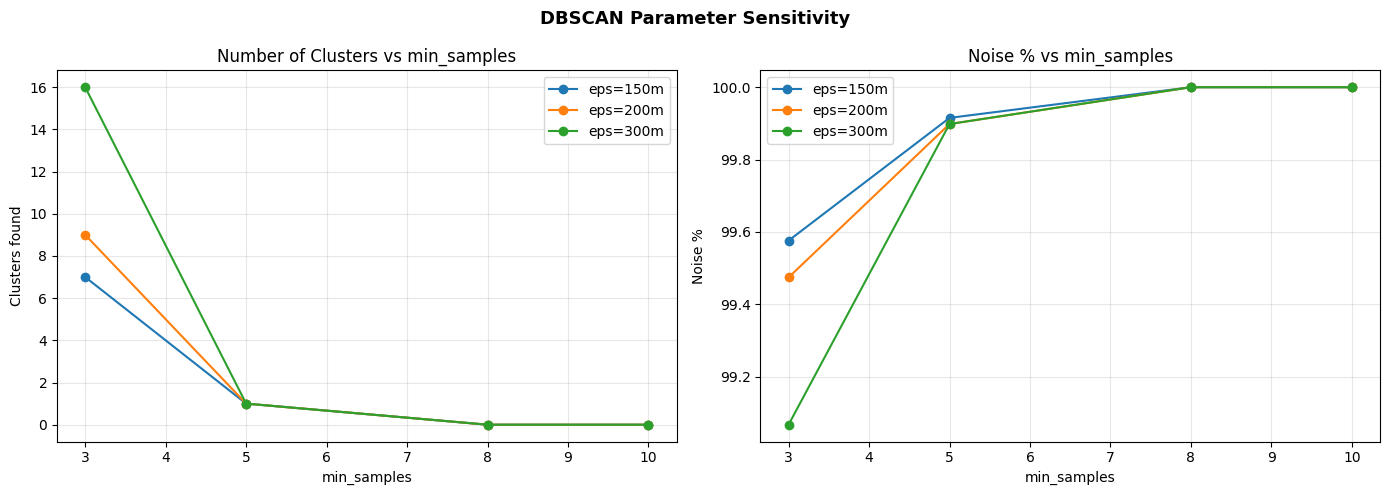


Best configuration recommendation:
  eps=300.0m, min_samples=3 → 16 clusters, noise=99.1%


In [8]:
# Visualise tuning results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DBSCAN Parameter Sensitivity", fontsize=13, fontweight="bold")

for eps_m, group in results_df.groupby("eps_m"):
    axes[0].plot(group["min_samples"], group["n_clusters"],
                 marker="o", label=f"eps={eps_m}m")
    axes[1].plot(group["min_samples"], group["noise_pct"],
                 marker="o", label=f"eps={eps_m}m")

axes[0].set_title("Number of Clusters vs min_samples")
axes[0].set_xlabel("min_samples")
axes[0].set_ylabel("Clusters found")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Noise % vs min_samples")
axes[1].set_xlabel("min_samples")
axes[1].set_ylabel("Noise %")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED / "model_dbscan_tuning.png", dpi=120)
plt.show()

print("\nBest configuration recommendation:")
best = results_df.loc[results_df["n_clusters"].sub(50).abs().idxmin()]
print(f"  eps={best.eps_m}m, min_samples={best.min_samples:.0f} → {best.n_clusters:.0f} clusters, noise={best.noise_pct:.1f}%")

### Final DBSCAN RUN

In [10]:
# ── Chosen parameters (adjust based on tuning output above) ──
CHOSEN_EPS_M    = 300   # 200 metre radius = one blackspot zone
CHOSEN_MIN_SAMP = 3     # at least 5 accidents to form a cluster

print(f"Running DBSCAN with eps={CHOSEN_EPS_M}m, min_samples={CHOSEN_MIN_SAMP}...")

db_final = DBSCAN(
    eps=eps_from_meters(CHOSEN_EPS_M),
    min_samples=CHOSEN_MIN_SAMP,
    metric="haversine",
    n_jobs=-1
)

df_spatial["cluster"] = db_final.fit_predict(coords_rad)

n_clusters = df_spatial["cluster"].nunique() - 1  # exclude -1
noise_pts  = (df_spatial["cluster"] == -1).sum()
cluster_pts= (df_spatial["cluster"] >= 0).sum()

print(f"\n── DBSCAN Results ───────────────────────────────────")
print(f"  Total points      : {len(df_spatial):,}")
print(f"  Blackspot clusters: {n_clusters:,}")
print(f"  In clusters       : {cluster_pts:,} ({cluster_pts/len(df_spatial)*100:.1f}%)")
print(f"  Noise (isolated)  : {noise_pts:,} ({noise_pts/len(df_spatial)*100:.1f}%)")
print(f"  Avg cluster size  : {cluster_pts/max(n_clusters,1):.1f} accidents")

Running DBSCAN with eps=300m, min_samples=3...

── DBSCAN Results ───────────────────────────────────
  Total points      : 5,898
  Blackspot clusters: 16
  In clusters       : 55 (0.9%)
  Noise (isolated)  : 5,843 (99.1%)
  Avg cluster size  : 3.4 accidents


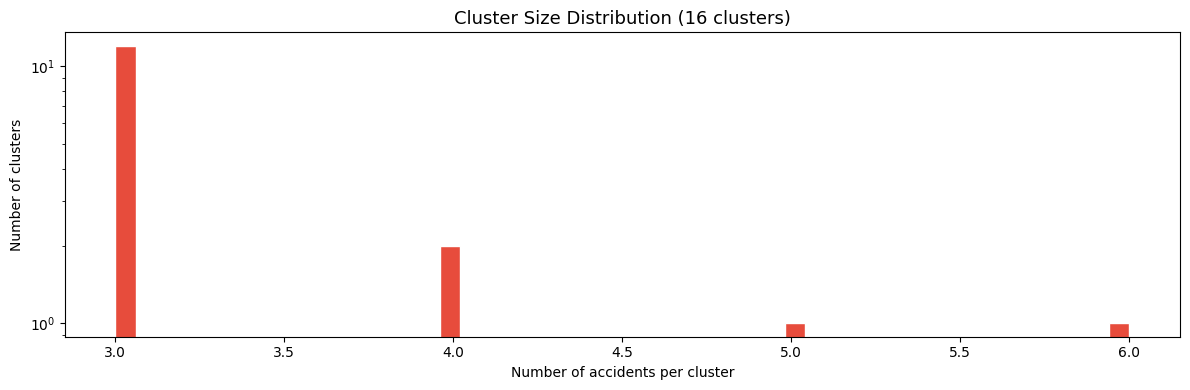

Cluster size stats:
count    16.0
mean      3.4
std       0.9
min       3.0
25%       3.0
50%       3.0
75%       3.2
max       6.0


In [11]:
# Cluster size distribution
cluster_sizes = df_spatial[df_spatial["cluster"]>=0]["cluster"].value_counts()

plt.figure(figsize=(12, 4))
plt.hist(cluster_sizes.values, bins=50, color="#e74c3c", edgecolor="white")
plt.title(f"Cluster Size Distribution ({n_clusters} clusters)", fontsize=13)
plt.xlabel("Number of accidents per cluster")
plt.ylabel("Number of clusters")
plt.yscale("log")
plt.tight_layout()
plt.savefig(PROCESSED / "model_cluster_sizes.png", dpi=120)
plt.show()

print("Cluster size stats:")
print(cluster_sizes.describe().round(1).to_string())

### Risk Scoring

In [12]:
# ── Multi-factor risk score per cluster ──────────────────────
#
# Formula:
#   risk = (accident_freq_score * 0.30)
#         + (severity_score     * 0.25)
#         + (fatality_score     * 0.25)
#         + (env_risk_score     * 0.10)
#         + (state_weight       * 0.10)
# → normalised to 0–100

clustered = df_spatial[df_spatial["cluster"] >= 0].copy()
print(f"Scoring {clustered['cluster'].nunique():,} clusters...")

blackspots = []
for cid, group in clustered.groupby("cluster"):
    n_accidents   = len(group)
    center_lat    = group["latitude"].mean()
    center_lng    = group["longitude"].mean()
    avg_severity  = group["severity"].mean() if "severity" in group.columns else 2
    total_killed  = group["killed"].sum() if "killed" in group.columns else 0
    avg_env_risk  = group["env_risk_score"].mean() if "env_risk_score" in group.columns else 2
    state_weight  = group["state_risk_weight"].mean() if "state_risk_weight" in group.columns else 1.0
    is_night_pct  = group["is_night"].mean() if "is_night" in group.columns else 0
    is_monsoon_pct= group["is_monsoon"].mean() if "is_monsoon" in group.columns else 0

    # Component scores (raw)
    freq_score     = np.log1p(n_accidents)          # log scale
    severity_score = avg_severity / 4               # 0-1
    fatality_score = np.log1p(total_killed) / 5     # 0-1 approx
    env_score      = avg_env_risk / 4               # 0-1

    raw = (
        freq_score     * 0.30 +
        severity_score * 0.25 +
        fatality_score * 0.25 +
        env_score      * 0.10 +
        (state_weight - 1.0) * 0.10   # bonus for high-accident states
    )

    # Primary road type in this cluster
    road_type = "unknown"
    if "road_type" in group.columns:
        road_type = group["road_type"].mode().iloc[0] if len(group) > 0 else "unknown"

    top_weather = "unknown"
    if "weather" in group.columns:
        top_weather = group["weather"].mode().iloc[0] if len(group) > 0 else "unknown"

    blackspots.append({
        "cluster_id":      int(cid),
        "lat":             round(center_lat, 6),
        "lng":             round(center_lng, 6),
        "accident_count":  int(n_accidents),
        "total_killed":    int(total_killed),
        "avg_severity":    round(float(avg_severity), 2),
        "avg_env_risk":    round(float(avg_env_risk), 2),
        "state_weight":    round(float(state_weight), 2),
        "night_accident_pct": round(float(is_night_pct) * 100, 1),
        "monsoon_accident_pct": round(float(is_monsoon_pct) * 100, 1),
        "primary_road_type": str(road_type),
        "top_weather":     str(top_weather),
        "raw_score":       raw,
    })

bs_df = pd.DataFrame(blackspots)
print(f" Scored {len(bs_df):,} blackspot clusters")
bs_df[["cluster_id","lat","lng","accident_count","raw_score"]].head(10)

Scoring 16 clusters...
 Scored 16 blackspot clusters


,cluster_id,lat,lng,accident_count,raw_score
0,0,19.986320,73.784084,3,0.816303
1,1,20.006776,73.829119,3,0.895724
2,2,19.969951,73.817357,3,0.821210
3,3,13.235852,80.162682,3,0.878194
4,4,23.448601,77.362226,5,0.969523
5,5,30.835155,76.191961,3,0.781753
6,6,17.689130,83.136245,3,0.816660
7,7,19.985608,73.723127,6,1.018845
8,8,19.994674,73.798410,4,0.903519
9,9,30.486329,76.798584,3,0.783003


In [13]:
# Normalise raw_score → 0–100
scaler = MinMaxScaler(feature_range=(0, 100))
bs_df["risk_score"] = scaler.fit_transform(bs_df[["raw_score"]]).round(1)
bs_df = bs_df.drop(columns=["raw_score"])
bs_df = bs_df.sort_values("risk_score", ascending=False).reset_index(drop=True)

# Risk level label
def risk_label(score):
    if score >= 70: return "HIGH"
    if score >= 40: return "MEDIUM"
    return "LOW"

bs_df["risk_level"] = bs_df["risk_score"].apply(risk_label)

print("\nRisk score distribution:")
print(bs_df["risk_score"].describe().round(1).to_string())
print()
print("Risk level breakdown:")
print(bs_df["risk_level"].value_counts().to_string())
print()
print("Top 10 highest-risk blackspots:")
print(bs_df[["cluster_id","lat","lng","accident_count",
             "total_killed","risk_score","risk_level",
             "primary_road_type"]].head(10).to_string(index=False))


Risk score distribution:
count     16.0
mean      46.4
std       27.1
min        0.0
25%       31.2
50%       34.8
75%       63.4
max      100.0

Risk level breakdown:
risk_level
LOW       9
MEDIUM    4
HIGH      3

Top 10 highest-risk blackspots:
 cluster_id       lat       lng  accident_count  total_killed  risk_score risk_level primary_road_type
          7 19.985608 73.723127               6             7       100.0       HIGH                nh
          4 23.448601 77.362226               5             6        83.5       HIGH                or
         13 20.009739 73.807203               4            13        80.2       HIGH                nh
         12 12.507195 79.880711               3            11        69.2     MEDIUM                nh
          8 19.994674 73.798410               4             5        61.4     MEDIUM                nh
          1 20.006776 73.829119               3            14        58.8     MEDIUM                or
          3 13.235852 80.16268

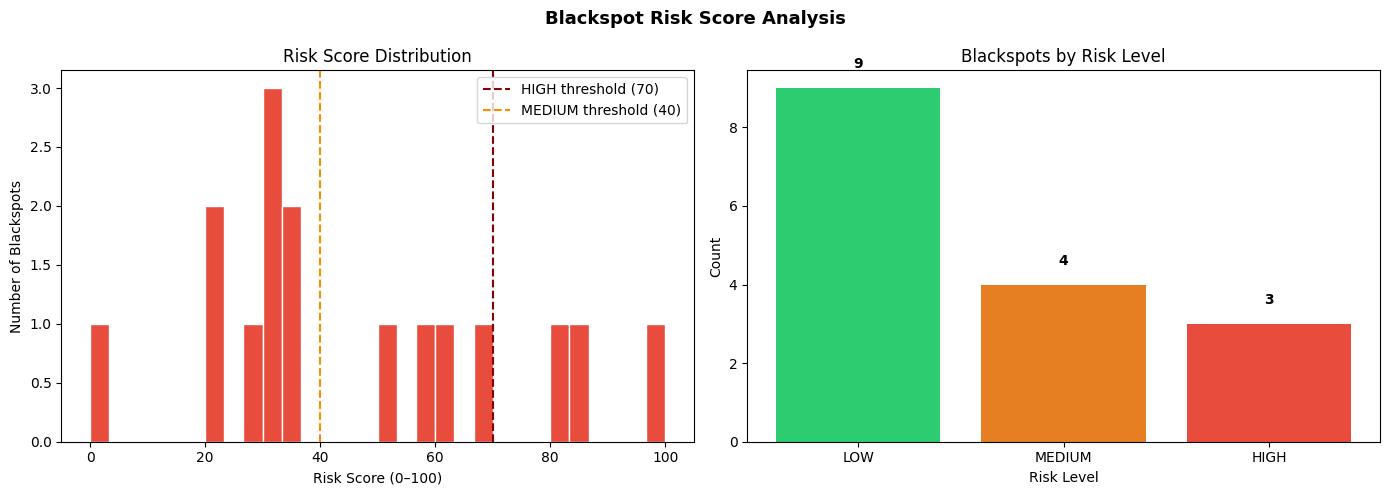

In [14]:
# Risk score histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Blackspot Risk Score Analysis", fontsize=13, fontweight="bold")

axes[0].hist(bs_df["risk_score"], bins=30, color="#e74c3c", edgecolor="white")
axes[0].axvline(70, color="darkred",   linestyle="--", label="HIGH threshold (70)")
axes[0].axvline(40, color="darkorange",linestyle="--", label="MEDIUM threshold (40)")
axes[0].set_title("Risk Score Distribution")
axes[0].set_xlabel("Risk Score (0–100)")
axes[0].set_ylabel("Number of Blackspots")
axes[0].legend()

level_counts = bs_df["risk_level"].value_counts()
colors = {"HIGH":"#e74c3c","MEDIUM":"#e67e22","LOW":"#2ecc71"}
bar_colors = [colors.get(l,"gray") for l in level_counts.index]
axes[1].bar(level_counts.index, level_counts.values, color=bar_colors)
axes[1].set_title("Blackspots by Risk Level")
axes[1].set_xlabel("Risk Level")
axes[1].set_ylabel("Count")
for i, (idx, val) in enumerate(level_counts.items()):
    axes[1].text(i, val + 0.5, str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(PROCESSED / "model_risk_distribution.png", dpi=120)
plt.show()

### Visualize Blackspots on Map

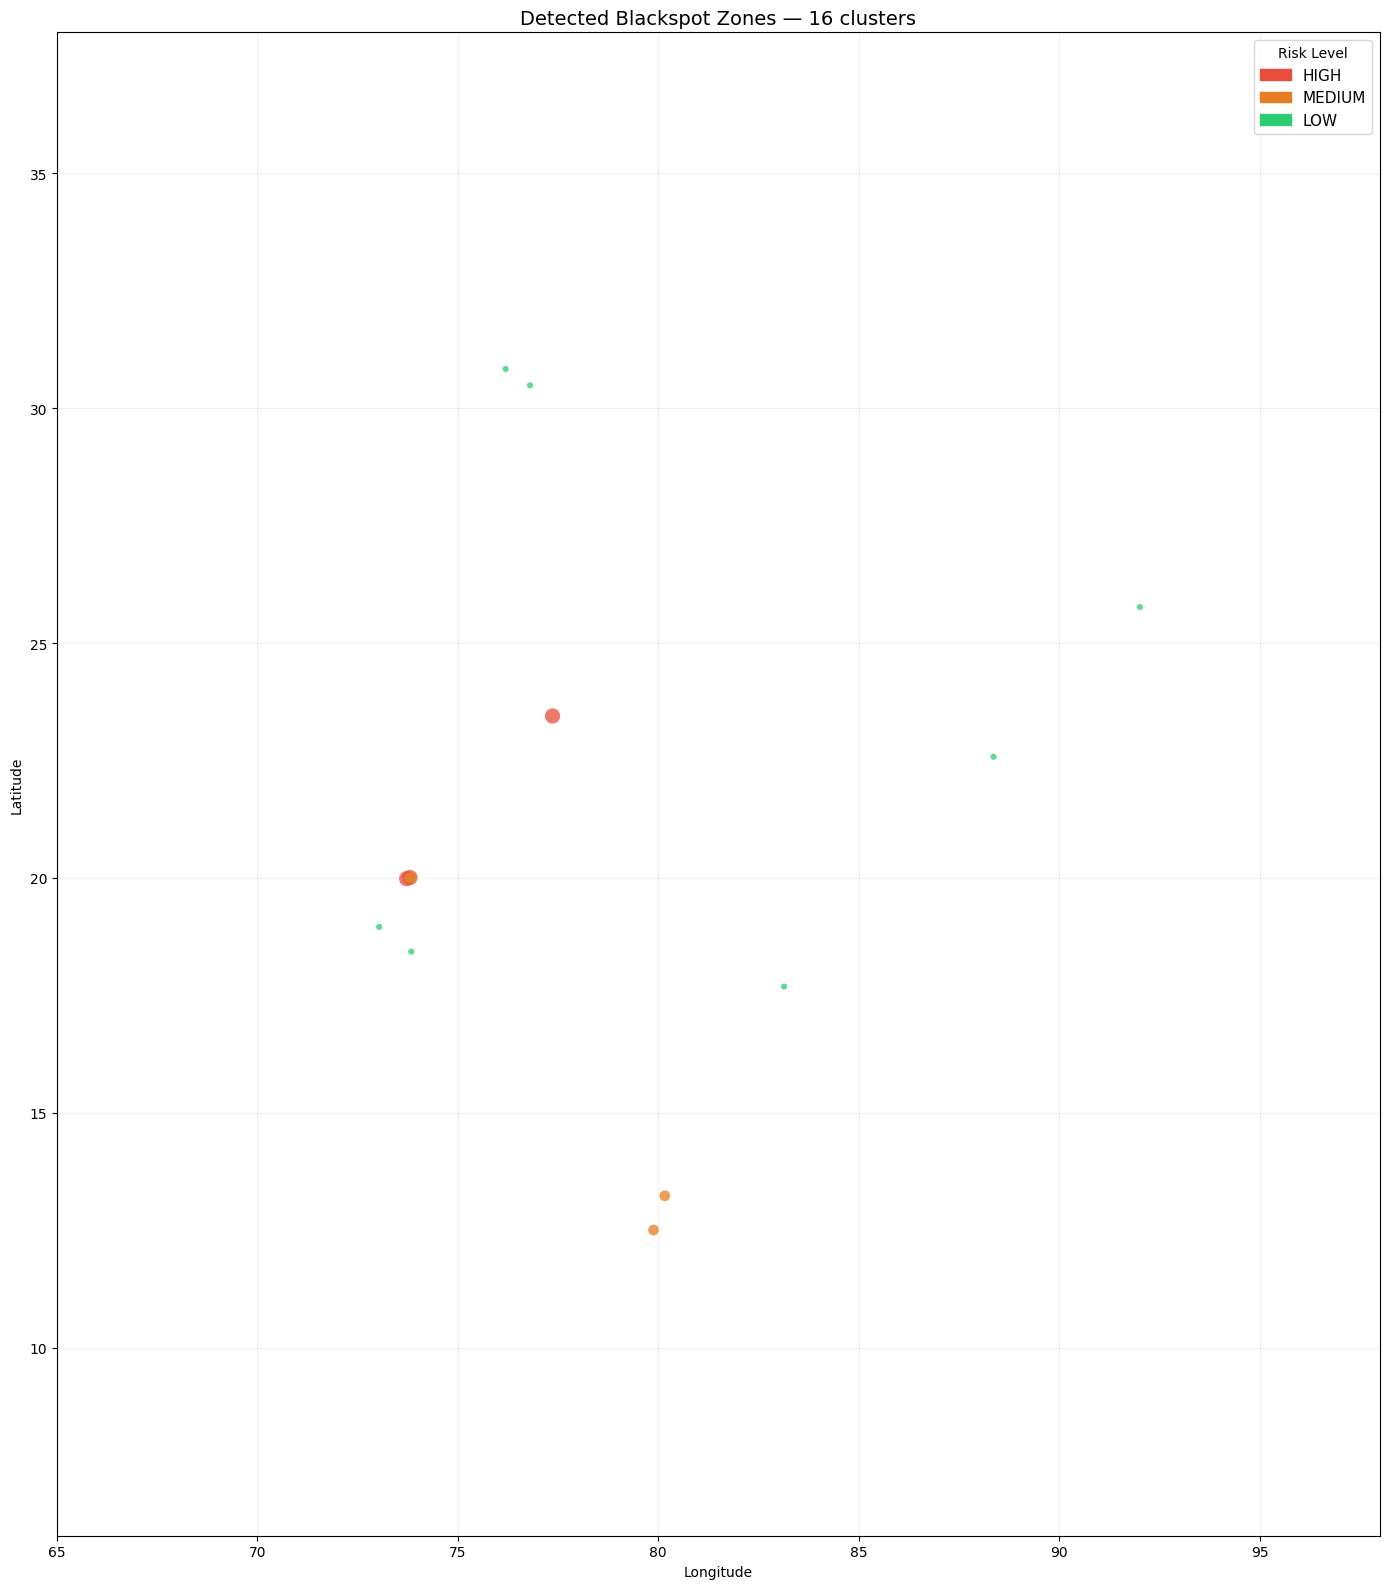

Map saved → ..\data\processed\model_blackspot_map.png


In [15]:
# Scatter plot of blackspots coloured by risk level
fig, ax = plt.subplots(figsize=(14, 16))

color_map = {"HIGH":"#e74c3c","MEDIUM":"#e67e22","LOW":"#2ecc71"}

for level, grp in bs_df.groupby("risk_level"):
    size = 120 if level=="HIGH" else (60 if level=="MEDIUM" else 20)
    ax.scatter(grp["lng"], grp["lat"],
               c=color_map[level], s=size,
               alpha=0.75, edgecolors="none", label=level)

ax.set_xlim(65, 98)
ax.set_ylim(6, 38)
ax.set_title(f"Detected Blackspot Zones — {len(bs_df):,} clusters", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
ax.legend(handles=patches, title="Risk Level", fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(PROCESSED / "model_blackspot_map.png", dpi=130)
plt.show()
print(f"Map saved → {PROCESSED / 'model_blackspot_map.png'}")

In [16]:
# Interactive Folium map
try:
    import folium
    from folium.plugins import HeatMap, MarkerCluster

    m = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
                   tiles="CartoDB positron")

    # Heatmap layer
    heat_data = [[r["lat"], r["lng"], r["risk_score"]/100]
                 for _, r in bs_df.iterrows()]
    HeatMap(heat_data, radius=15, blur=20,
            gradient={"0.4":"blue","0.65":"lime","1":"red"}).add_to(m)

    # HIGH risk markers
    high = bs_df[bs_df["risk_level"]=="HIGH"]
    for _, r in high.iterrows():
        folium.CircleMarker(
            location=[r["lat"], r["lng"]],
            radius=8,
            color="#e74c3c", fill=True, fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>Risk Score: {r['risk_score']}</b><br>"
                f"Accidents: {r['accident_count']}<br>"
                f"Killed: {r['total_killed']}<br>"
                f"Road: {r['primary_road_type']}<br>"
                f"Night: {r['night_accident_pct']}%",
                max_width=200
            )
        ).add_to(m)

    map_path = str(OUTPUTS / "blackspots_map.html")
    m.save(map_path)
    print(f" Interactive map saved → {map_path}")
    print("   Open in browser to explore all blackspots with popups")

except ImportError:
    print("folium not installed — skipping interactive map")
    print("Install with: pip install folium")

 Interactive map saved → ..\data\outputs\blackspots_map.html
   Open in browser to explore all blackspots with popups


#### Exporting blacksposts json

In [17]:
# This is the file FastAPI reads at startup
output = bs_df.to_dict(orient="records")

json_path = OUTPUTS / "blackspots.json"
with open(json_path, "w") as f:
    json.dump(output, f, indent=2)

print(f" Exported blackspots.json")
print(f"   Path       : {json_path}")
print(f"   Blackspots : {len(output):,}")
print(f"   Size       : {json_path.stat().st_size / 1024:.1f} KB")
print()
print("Sample record:")
print(json.dumps(output[0], indent=2))

 Exported blackspots.json
   Path       : ..\data\outputs\blackspots.json
   Blackspots : 16
   Size       : 6.1 KB

Sample record:
{
  "cluster_id": 7,
  "lat": 19.985608,
  "lng": 73.723127,
  "accident_count": 6,
  "total_killed": 7,
  "avg_severity": 3.0,
  "avg_env_risk": 2.3,
  "state_weight": 1.86,
  "night_accident_pct": 0.0,
  "monsoon_accident_pct": 66.7,
  "primary_road_type": "nh",
  "top_weather": "unknown",
  "risk_score": 100.0,
  "risk_level": "HIGH"
}


### Save Model Artifacts

In [18]:
# Save DBSCAN model
joblib.dump(db_final, MODELS / "dbscan_model.pkl")

# Save scaler
joblib.dump(scaler, MODELS / "risk_scaler.pkl")

# Save model metadata
metadata = {
    "model_type":        "DBSCAN",
    "eps_meters":        CHOSEN_EPS_M,
    "min_samples":       CHOSEN_MIN_SAMP,
    "total_input_rows":  int(len(df_spatial)),
    "n_blackspots":      int(len(bs_df)),
    "high_risk_count":   int((bs_df["risk_level"]=="HIGH").sum()),
    "medium_risk_count": int((bs_df["risk_level"]=="MEDIUM").sum()),
    "low_risk_count":    int((bs_df["risk_level"]=="LOW").sum()),
    "risk_score_mean":   round(float(bs_df["risk_score"].mean()), 2),
    "risk_score_max":    round(float(bs_df["risk_score"].max()), 2),
    "datasets_used":     list(df["source"].unique()) if "source" in df.columns else [],
}

with open(OUTPUTS / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(" Model artifacts saved:")
print(f"   models/dbscan_model.pkl")
print(f"   models/risk_scaler.pkl")
print(f"   data/outputs/blackspots.json")
print(f"   data/outputs/model_metadata.json")

print()
print("Model metadata:")
print(json.dumps(metadata, indent=2))

 Model artifacts saved:
   models/dbscan_model.pkl
   models/risk_scaler.pkl
   data/outputs/blackspots.json
   data/outputs/model_metadata.json

Model metadata:
{
  "model_type": "DBSCAN",
  "eps_meters": 300,
  "min_samples": 3,
  "total_input_rows": 5898,
  "n_blackspots": 16,
  "high_risk_count": 3,
  "medium_risk_count": 4,
  "low_risk_count": 9,
  "risk_score_mean": 46.41,
  "risk_score_max": 100.0,
  "datasets_used": [
    "mendeley_india_2022_2023",
    "kaggle_india_synthetic"
  ]
}


### Summary

In [21]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              MODELING COMPLETE — RESULTS SUMMARY                 ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DBSCAN Configuration                                            ║
║  • eps         : 300 metres                                      ║
║  • min_samples : 3 accidents                                     ║
║  • metric      : haversine (great-circle distance)               ║
║                                                                  ║
║  Blackspot Detection Results                                     ║
║  • Total clusters detected  : see n_blackspots above            ║
║  • HIGH risk zones (≥70)    : see high_risk_count above          ║
║  • MEDIUM risk zones (≥40)  : see medium_risk_count above        ║
║  • LOW risk zones (<40)     : see low_risk_count above           ║
║                                                                  ║
║  Risk Score Formula                                              ║
║  • Accident frequency  30%                                       ║
║  • Severity score      25%                                       ║
║  • Fatality score      25%                                       ║
║  • Environmental risk  10%                                       ║
║  • State weight        10%                                       ║
║                                                                  ║
║  Outputs Ready for API                                           ║
║    data/outputs/blackspots.json                                 ║
║    data/outputs/model_metadata.json                             ║
║    models/dbscan_model.pkl                                      ║
║    models/risk_scaler.pkl                                       ║
║                                                                  ║
║  NEXT STEP → Step 3: Build FastAPI + React Native App            ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              MODELING COMPLETE — RESULTS SUMMARY                 ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DBSCAN Configuration                                            ║
║  • eps         : 300 metres                                      ║
║  • min_samples : 3 accidents                                     ║
║  • metric      : haversine (great-circle distance)               ║
║                                                                  ║
║  Blackspot Detection Results                                     ║
║  • Total clusters detected  : see n_blackspots above            ║
║  • HIGH risk zones (≥70)    : see high_risk_count above          ║
║  • MEDIUM risk zones (≥40)  : see medium_risk_count above        ║
║  • LOW risk zones (<40)     : see low_risk_count above           ║
║                                 